# CrisisNLP_R1

---

## A. Original

### CrisisNLP_labeled_data_crowdflower

- In this folder, each dataset contains more than 1,500 labeled tweets
- We used paid workers from the CrowdFlower crowdsourcing platform for the labeling
- At least three different workers were required to agree on a label to finalize a tweet label
- No worker was allowed to perform more than 200 tasks
- Detailed crowdsourcing tasks description is provided inside each folder
- No browsing to URLs in tweets.

#### Category---description:

1. Injured or dead people---Reports of casualties and/or injured people due to the crisis
2. Missing, trapped, or found people---Reports and/or questions about missing or found people
3. Displaced people and evacuations---People who have relocated due to the crisis, even for a short time (includes evacuations)
4. Infrastructure and utilities damage---Reports of damaged buildings, roads, bridges, or utilities/services interrupted or restored
5. Donation needs or offers or volunteering services---Reports of urgent needs or donations of shelter and/or supplies such as food, water, clothing, money, medical supplies or blood; and volunteering services
6. Caution and advice---Reports of warnings issued or lifted, guidance and tips
7. Sympathy and emotional support---Prayers, thoughts, and emotional support
8. Other useful information---Other useful information that helps understand the situation
9. Not related or irrelevant---Unrelated to the situation or irrelevant 

### CrisisNLP_volunteers_labeled_data

- We used volunteers through the AIDR platform (http://aidr.qcri.org/) to label this data
- At least three different workers were required to agree on a label before a task is finalized
- Each folder contains crowdsourcing task details


#### Label---Description

* Informative---Contributes useful information enhancing situational awareness
* Personal only---Personal and only useful to a small circle of family/friends of the author
* Not related to crisis---Not related to the crisis

### Ref

Muhammad Imran, Prasenjit Mitra, Carlos Castillo: Twitter as a Lifeline: Human-annotated Twitter Corpora for NLP of Crisis-related Messages. In Proceedings of the 10th Language Resources and Evaluation Conference (LREC), pp. 1638-1643. May 2016, Portorož, Slovenia.

Muhammad Imran, Carlos Castillo, Ji Lucas, Patrick Meier, and Sarah Vieweg. AIDR: Artificial Intelligence for Disaster Response. In Proceedings of the 23th International Conference on World Wide Web (WWW) Companion, 2014. Seoul, Korea.


## B. Overview

In [1]:
from pathlib import Path
import os
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

dataset_path = Path(os.getenv("DATASETS_PATH")) / 'CrisisNLP_R1'

### B.1 CrisisNLP_labeled_data_crowdflower

In [2]:
events_CF = {
    '2013_Pakistan_eq': {
        'country': 'Pakistan',
        'event_type': 'earthquake',
        'event_name': '2013 Pakistan Earthquake',
        'year': 2013,
    },
    '2014_California_Earthquake': {
        'country': 'US',
        'event_type': 'earthquake',
        'event_name': '2014 California Earthquake',
        'year': 2014,
    },
    '2014_Chile_Earthquake_en': {
        'country': 'Chile',
        'event_type': 'earthquake',
        'event_name': '2014 Chile Earthquake',
        'year': 2014,
    },
    # '2014_ebola_cf': {
    #     'country': 'Africa',
    #     'event_type': 'disease',
    #     'event_name': '2014 Ebola Outbreak',
    #     'year': 2014,
    # },
    '2014_Hurricane_Odile_Mexico_en': {
        'country': 'Mexico',
        'event_type': 'storm',
        'event_name': '2014 Hurricane Odile Mexico',
        'year': 2014,
    },
    '2014_India_floods': {
        'country': 'India',
        'event_type': 'flood',
        'event_name': '2014 India Floods',
        'year': 2014,
    },
    # '2014_Middle_East_Respiratory_Syndrome_en': {
    #     'country': 'Middle East',
    #     'event_type': 'disease',
    #     'event_name': '2014 Middle East Respiratory Syndrome',
    #     'year': 2014,
    # },
    '2014_Pakistan_floods': {
        'country': 'Pakistan',
        'event_type': 'flood',
        'event_name': '2014 Pakistan Floods',
        'year': 2014,
    },
    '2014_Philippines_Typhoon_Hagupit_en': {
        'country': 'Philippines',
        'event_type': 'storm',
        'event_name': '2014 Philippines Typhoon Hagupit',
        'year': 2014,
    },
    '2015_Cyclone_Pam_en': {
        'country': 'Vanuatu',
        'event_type': 'storm',
        'event_name': '2015 Cyclone Pam',
        'year': 2015,
    },
    '2015_Nepal_Earthquake_en': {
        'country': 'Nepal',
        'event_type': 'earthquake',
        'event_name': '2015 Nepal Earthquake',
        'year': 2015,
    },
}

In [3]:
base_dir = dataset_path / 'CrisisNLP_labeled_data_crowdflower'
all_files = sorted(base_dir.rglob('*.tsv'))

dfs = []
for file in all_files:
    parent_name = file.parent.name
    print(f'Processing: {parent_name}')
    if parent_name not in events_CF:
        print(f'Skipping: {parent_name}')
        continue
    data = events_CF[parent_name]
    df = pd.read_csv(file, sep='\t', encoding='utf_8')
    df['tweet_id'] = df['tweet_id'].str.strip("'").astype('int64')
    df['event_type'] = data['event_type']
    df['event_name'] = data['event_name']
    df['country'] = data['country']
    df['year'] = data['year']
    df['dataset'] = 'CrisisNLP_R1'
    df['meta'] = df.apply(
        lambda x: {
            'file_name': file.name,
            'sub_dataset': 'Crowdflower'
            },
        axis=1)
    dfs.append(df)

df_CF = pd.concat(dfs, ignore_index=True)

Processing: 2013_Pakistan_eq
Processing: 2014_California_Earthquake
Processing: 2014_Chile_Earthquake_cl
Skipping: 2014_Chile_Earthquake_cl
Processing: 2014_Chile_Earthquake_en
Processing: 2014_Hurricane_Odile_Mexico_en
Processing: 2014_India_floods
Processing: 2014_Middle_East_Respiratory_Syndrome_en
Skipping: 2014_Middle_East_Respiratory_Syndrome_en
Processing: 2014_Pakistan_floods
Processing: 2014_Philippines_Typhoon_Hagupit_en
Processing: 2014_ebola_cf
Skipping: 2014_ebola_cf
Processing: 2015_Cyclone_Pam_en
Processing: 2015_Nepal_Earthquake_en


In [4]:
print(f'Total rows: {len(df_CF)}')
df_CF.head(10)

Total rows: 17382


,tweet_id,tweet_text,label,event_type,event_name,country,year,dataset,meta
0,383600460340666369,RT @Faiz_Baluch: #BalochistanEarthQuake Pakist...,other_useful_information,earthquake,2013 Pakistan Earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
1,383790723222364161,#Earthquake 2013-09-28 02:39:43 (M5.0) EAST OF...,other_useful_information,earthquake,2013 Pakistan Earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
2,384232048124518400,#earthquake M2.2: Puerto Rico region http://t....,other_useful_information,earthquake,2013 Pakistan Earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
3,384860484643475456,#PAKISTAN: #NASA releases images of Pakistan's...,other_useful_information,earthquake,2013 Pakistan Earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
4,383407962619772928,"【#USGS #alert】 M 1.5, Central Alaska: Septembe...",other_useful_information,earthquake,2013 Pakistan Earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
5,384275270082887680,RT @AQpk: RT @313syiSitak: #YFK volunteers sha...,donation_needs_or_offers_or_volunteering_services,earthquake,2013 Pakistan Earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
6,382846453221036032,"@HamidMirGEO: It is ridiculous, rubbish. Now y...",not_related_or_irrelevant,earthquake,2013 Pakistan Earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
7,384223701144576001,@mosharrafzaidi #Pakistan #Peshawar A Message ...,not_related_or_irrelevant,earthquake,2013 Pakistan Earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
8,383596911598768128,RT @CNBCPAKISTAN: Minister of State Sheikh Aft...,injured_or_dead_people,earthquake,2013 Pakistan Earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
9,384041956038303744,RT @kkfpk: Pic-9 #KKF send relief goods for #B...,donation_needs_or_offers_or_volunteering_services,earthquake,2013 Pakistan Earthquake,Pakistan,2013,CrisisNLP_R1,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...


In [5]:
print(df_CF['label'].value_counts())

label
other_useful_information                             5165
donation_needs_or_offers_or_volunteering_services    2452
injured_or_dead_people                               2321
not_related_or_irrelevant                            2230
sympathy_and_emotional_support                       1887
infrastructure_and_utilities_damage                  1394
caution_and_advice                                   1011
displaced_people_and_evacuations                      547
missing_trapped_or_found_people                       375
Name: count, dtype: int64


### B.2 CrisisNLP_volunteers_labeled_data

In [6]:
events_VO = {
    '2014_California_Earthquake': {
        'country' : 'US',
        'event_type' : 'earthquake',
        'event_name' : '2014 California Earthquake',
        'year' : 2014,
    },
    '2014_Chile_Earthquake_en': {
        'country' : 'Chile',
        'event_type' : 'earthquake',
        'event_name' : '2014 Chile Earthquake',
        'year' : 2014,
    },
    '2014_Hurricane_Odile_Mexico_en': {
        'country' : 'Mexico',
        'event_type' : 'storm',
        'event_name' : '2014 Hurricane Odile Mexico',
        'year' : 2014,
    },
    '2014_Iceland_Volcano_en': {
        'country' : 'Iceland',
        'event_type' : 'volcano',
        'event_name' : '2014 Iceland Volcano',
        'year' : 2014,
    },
    # '2014_Malaysia_Airline_MH370_en': {
    #     'country' : 'Malaysia',
    #     'event_type' : 'artificial_incident',
    #     'event_name' : '2014 Malaysia Airline MH370',
    #     'year' : 2014,
    # },
    # '2014_Middle_East_Respiratory_Syndrome_en': {
    #     'country' : 'Middle East',
    #     'event_type' : 'disease',
    #     'event_name' : '2014 Middle East Respiratory Syndrome',
    #     'year' : 2014,
    # },
    '2014_Philippines_Typhoon_Hagupit_en': {
        'country' : 'Philippines',
        'event_type' : 'storm',
        'event_name' : '2014 Philippines Typhoon Hagupit',
        'year' : 2014,
    },
    '2015_Cyclone_Pam_en': {
        'country' : 'Vanuatu',
        'event_type' : 'storm',
        'event_name' : '2015 Cyclone Pam',
        'year' : 2015,
    },
    '2015_Nepal_Earthquake_en': {
        'country' : 'Nepal',
        'event_type' : 'earthquake',
        'event_name' : '2015 Nepal Earthquake',
        'year' : 2015,
    },
    'Landslides_Worldwide_en': {
        'country' : 'Worldwide',
        'event_type' : 'earthquake',
        'event_name' : 'Landslides Worldwide',
        'year' : -1,
    },
}

In [7]:
base_dir = dataset_path / 'CrisisNLP_volunteers_labeled_data'
all_files = sorted(base_dir.rglob('*.csv'))

meta_columns = ['file_name',
                'tweet_time', 'tweet_author', 'tweet_author_id', 'tweet_language',
                'tweet_lon', 'tweet_lat', 'tweet_url']

dfs = []
for file in all_files:
    parent_name = file.parent.name
    print(f'Processing: {parent_name}')
    if parent_name not in events_VO:
        print(f'Skipping: {parent_name}')
        continue

    df = pd.read_csv(file, encoding='cp437')
    df.columns = df.columns.str.strip()
    data = events_VO[parent_name]
    df['tweet_id'] = df['tweet_id'].str.strip("'").astype('int64')
    df['event_type'] = data['event_type']
    df['event_name'] = data['event_name']
    df['country'] = data['country']
    df['year'] = data['year']
    df['file_name'] = file.name
    df['dataset'] = 'CrisisNLP_R1'
    df['meta'] = df[meta_columns].to_dict(orient='records')

    df.drop(columns=meta_columns, inplace=True)
    dfs.append(df)

df_VO = pd.concat(dfs, ignore_index=True)

Processing: 2014_California_Earthquake
Processing: 2014_Chile_Earthquake_cl
Skipping: 2014_Chile_Earthquake_cl
Processing: 2014_Chile_Earthquake_en
Processing: 2014_Hurricane_Odile_Mexico_en
Processing: 2014_Iceland_Volcano_en
Processing: 2014_Malaysia_Airline_MH370_en
Skipping: 2014_Malaysia_Airline_MH370_en
Processing: 2014_Middle_East_Respiratory_Syndrome_en
Skipping: 2014_Middle_East_Respiratory_Syndrome_en
Processing: 2014_Philippines_Typhoon_Hagupit_en
Processing: 2015_Cyclone_Pam_en
Processing: 2015_Nepal_Earthquake_en
Processing: Landslides_Worldwide_en
Processing: Landslides_Worldwide_esp
Skipping: Landslides_Worldwide_esp
Processing: Landslides_Worldwide_fr
Skipping: Landslides_Worldwide_fr


In [8]:
tweet_languages = df_VO['meta'].map(lambda meta: meta.get('tweet_language'))
print(tweet_languages.value_counts(dropna=False))

# Drop non-English tweets
df_VO = df_VO[tweet_languages == 'en'].reset_index(drop=True)

meta
en    24736
fr      448
es      222
it       54
Name: count, dtype: int64


In [9]:
print(f'Total rows: {len(df_VO)}')
df_VO.head(5)

Total rows: 24736


,tweet_id,tweet_text,label,event_type,event_name,country,year,dataset,meta
0,503866345822244864,"σ_ USA 592 Earthquake Earthquake rattles, does...",Infrastructure and utilities,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
1,503866373961809920,ë█ó ë█ó Earthquake #Earthquake California Eart...,Other relevant information,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
2,503866427322159104,WCVB Boston: California quake: Recovering afte...,Other relevant information,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
3,503866453280317440,I don't know. CALIFORNIA. if u had a winery th...,Not related or irrelevant,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
4,503866484461170688,"NOW: Possible #Timmies, #BurgerKing merger, #O...",Not related or irrelevant,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...


In [10]:
print(df_VO['label'].value_counts())

label
Not Informative                        6742
Not Relevant                           6279
Not physical landslide                 3236
Other Relevant Information             2906
Response Efforts                        994
Other relevant information              556
Sympathy and emotional support          545
Physical landslide                      531
Not related or irrelevant               477
Infrastructure Damage                   426
Humanitarian Aid Provided               323
Not related to crisis                   222
Other useful information                214
Caution and advice                      190
Informative                             161
Infrastructure and utilities            148
Injured or dead people                  115
Urgent Needs                            108
Volunteer or professional services       76
Requests for Help/Needs                  71
Personal updates, sympathy, support      66
Money                                    63
Injured and dead          

### B.3 Merge `volunteers` and `crowdflower` and to one



In [11]:
df_original = pd.concat([df_VO, df_CF], ignore_index=False)
print(f'Total rows in original dataset: {len(df_original)}')
df_original.head()

Total rows in original dataset: 42118


,tweet_id,tweet_text,label,event_type,event_name,country,year,dataset,meta
0,503866345822244864,"σ_ USA 592 Earthquake Earthquake rattles, does...",Infrastructure and utilities,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
1,503866373961809920,ë█ó ë█ó Earthquake #Earthquake California Eart...,Other relevant information,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
2,503866427322159104,WCVB Boston: California quake: Recovering afte...,Other relevant information,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
3,503866453280317440,I don't know. CALIFORNIA. if u had a winery th...,Not related or irrelevant,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
4,503866484461170688,"NOW: Possible #Timmies, #BurgerKing merger, #O...",Not related or irrelevant,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...


#### Remove duplicated

In [12]:
df_dup = df_original[df_original.duplicated(subset=["tweet_id"], keep=False)].sort_values("tweet_id")
print(f'Total duplicate rows: {len(df_dup)}')
df_dup.head(10)

Total duplicate rows: 168


,tweet_id,tweet_text,label,event_type,event_name,country,year,dataset,meta
193,451285334920142848,Nasa chille si papa :o I hope his alright :( #...,"Personal updates, sympathy, support",earthquake,2014 Chile Earthquake,Chile,2014,CrisisNLP_R1,"{'file_name': '2014_Chile_Earthquake_en.csv', ..."
4921,451285334920142848,Nasa chille si papa :o I hope his alright :( #...,sympathy_and_emotional_support,earthquake,2014 Chile Earthquake,Chile,2014,CrisisNLP_R1,{'file_name': '2014_Chile_Earthquake_en_CF_lab...
352,451380442110107648,No disruptions at #Chile #coppermines after 8....,Other useful information,earthquake,2014 Chile Earthquake,Chile,2014,CrisisNLP_R1,"{'file_name': '2014_Chile_Earthquake_en.csv', ..."
5188,451380442110107648,No disruptions at #Chile #coppermines after 8....,other_useful_information,earthquake,2014 Chile Earthquake,Chile,2014,CrisisNLP_R1,{'file_name': '2014_Chile_Earthquake_en_CF_lab...
380,451611530107183105,"Another big earthquake has occurred in Chile, ...",Other useful information,earthquake,2014 Chile Earthquake,Chile,2014,CrisisNLP_R1,"{'file_name': '2014_Chile_Earthquake_en.csv', ..."
4587,451611530107183105,"Another big earthquake has occurred in Chile, ...",other_useful_information,earthquake,2014 Chile Earthquake,Chile,2014,CrisisNLP_R1,{'file_name': '2014_Chile_Earthquake_en_CF_lab...
48,503870731831111680,Strong 6.0 #California #EarthQuake Surprises a...,Infrastructure and utilities,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
2784,503870731831111680,Strong 6.0 #California #EarthQuake Surprises a...,other_useful_information,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake_CF_l...
178,504284375115370496,Earthquake Warning Systems Exist. But Californ...,Other relevant information,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake.csv'...
2992,504284375115370496,Earthquake Warning Systems Exist. But Californ...,other_useful_information,earthquake,2014 California Earthquake,US,2014,CrisisNLP_R1,{'file_name': '2014_California_Earthquake_CF_l...


In [13]:
df_non_dupl = (
    df_original.sort_values(["tweet_id", "dataset"])
    .drop_duplicates(subset=["tweet_id"], keep="first")
    .reset_index(drop=True)
)
print(f'Total rows in cleaned dataset: {len(df_non_dupl)}')

Total rows in cleaned dataset: 42034


In [14]:
# TODO: Clean for duplicates in the 'tweet_text' column.
print(f"Number of duplicate tweets: {df_non_dupl['tweet_text'].duplicated().sum()}")

# # Remove duplicates
df_non_dupl = df_non_dupl.drop_duplicates(subset=['tweet_text'])

df_non_dupl['tweet_text'].value_counts()

Number of duplicate tweets: 350


tweet_text
Saddened by powerful 7.7 magn.earthquake that killed 250 people in #Pakistan. Condolences for victims&amp;families and hope for a quick recovery    1
Please consider donating to CARE and Save the Children. They do yeoman's work here. #TCPam #Vanuatu                                                 1
Cyclone Pam – Latest update 11:00am Tuesday 17th March: John Law, MetService Meteorologist. Cyclo... http://t.co/fsNVa6UZni #weathernews            1
RT @StarAdvertiser: Crew of Hokule'a hunker down as Cyclone Pam nears New Zealand http://t.co/Ihb5HI4JIm http://t.co/Fvem7uoOci                     1
RT @katastraphe007: @TMZ it's so shameful to disgrace sam's good name for a fake story! none of this is true and hurtful to me as his gf. p…        1
                                                                                                                                                   ..
Typhoon Hagupit makesσ╩landfall http://t.co/PBykzagSl8                                   

#### Map label

In [15]:
notrelevant = [
    'Not related or irrelevant',
    'Not related to crisis', 
    'Not informative',
    'No',
    'Not Informative',
    'Not relevant', 
    'Not Relevant',
    'Not physical landslide',
    'not_related_or_irrelevant' # df_CF
    ]
df_non_dupl['relevant'] = df_non_dupl['label'].apply(lambda x: False if x in notrelevant else True)
df_non_dupl.rename(columns={'label': 'original_label'}, inplace=True)
df_non_dupl = df_non_dupl[dataset_settings.dataset_extended_cols]

df_non_dupl.head()

,tweet_id,tweet_text,relevant,event_type,event_name,dataset,original_label,country,year,meta
0,382813501729017856,Saddened by powerful 7.7 magn.earthquake that ...,True,earthquake,2013 Pakistan Earthquake,CrisisNLP_R1,injured_or_dead_people,Pakistan,2013,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
1,382814139623931904,RT @Zarina_Baloch: More than 230 killed in maj...,True,earthquake,2013 Pakistan Earthquake,CrisisNLP_R1,injured_or_dead_people,Pakistan,2013,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
2,382814989817364480,#Pakistan #quake released frozen #methane that...,True,earthquake,2013 Pakistan Earthquake,CrisisNLP_R1,other_useful_information,Pakistan,2013,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
3,382818570058489857,RT @KaleemAltafi: #ReliefByKKF Send Relief Go...,True,earthquake,2013 Pakistan Earthquake,CrisisNLP_R1,donation_needs_or_offers_or_volunteering_services,Pakistan,2013,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...
4,382819416959758338,Situation of #Balochistan: 18000+ Balochs are ...,True,earthquake,2013 Pakistan Earthquake,CrisisNLP_R1,missing_trapped_or_found_people,Pakistan,2013,{'file_name': '2013_Pakistan_eq_CF_labeled_dat...


In [16]:
import csv
df_non_dupl.to_csv( 'datasets/CrisisNLP.csv', index=False, quoting=csv.QUOTE_ALL)

#### Verifying

In [17]:
df_non_dupl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41684 entries, 0 to 42033
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   tweet_id        41684 non-null  int64 
 1   tweet_text      41684 non-null  object
 2   relevant        41684 non-null  bool  
 3   event_type      41684 non-null  object
 4   event_name      41684 non-null  object
 5   dataset         41684 non-null  object
 6   original_label  41684 non-null  object
 7   country         41684 non-null  object
 8   year            41684 non-null  int64 
 9   meta            41684 non-null  object
dtypes: bool(1), int64(2), object(7)
memory usage: 3.2+ MB


In [18]:
df_non_dupl.describe(include='all')

,tweet_id,tweet_text,relevant,event_type,event_name,dataset,original_label,country,year,meta
count,4.168400e+04,41684,41684,41684,41684,41684,41684,41684,41684.000000,41684
unique,NaN,41684,2,4,11,1,47,10,NaN,24391
top,NaN,Saddened by powerful 7.7 magn.earthquake that ...,True,earthquake,2015 Nepal Earthquake,CrisisNLP_R1,Not Informative,Nepal,NaN,{'file_name': '2015_Nepal_Earthquake_en_CF_lab...
freq,NaN,1,22735,22227,12398,41684,6602,12398,NaN,2986
mean,5.421312e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1834.973707,NaN
std,5.275886e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,573.872804,NaN
min,3.828135e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.000000,NaN
25%,5.110686e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN
50%,5.419238e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000,NaN
75%,5.921633e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN


<Axes: xlabel='event_type'>

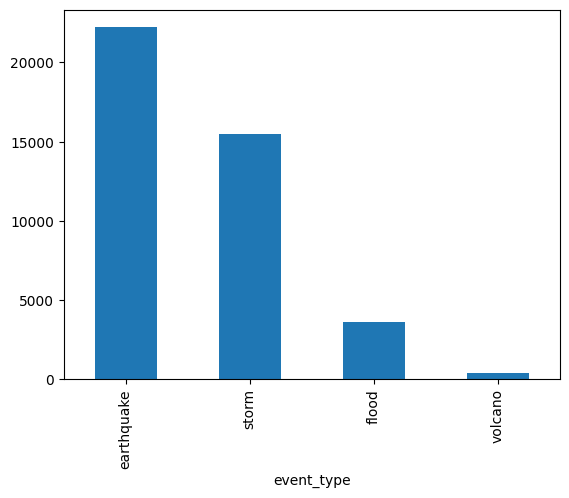

In [19]:
df_non_dupl['event_type'].value_counts().plot(kind='bar')

<Axes: xlabel='relevant'>

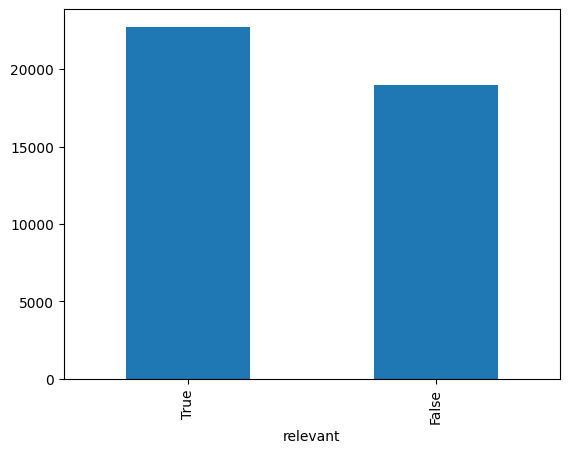

In [20]:
df_non_dupl['relevant'].value_counts().plot(kind='bar')